      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

Data types:
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary stats:
             math    science    english    history         p

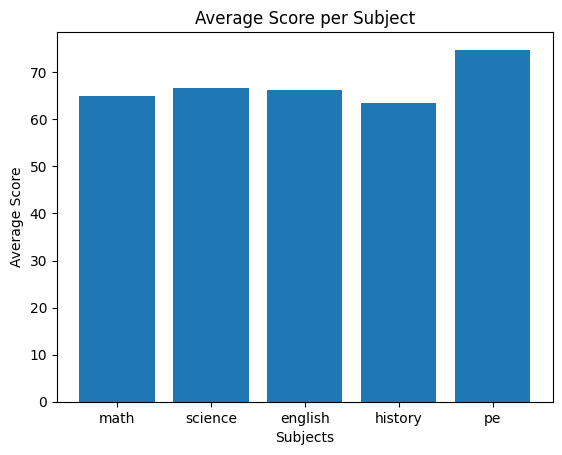

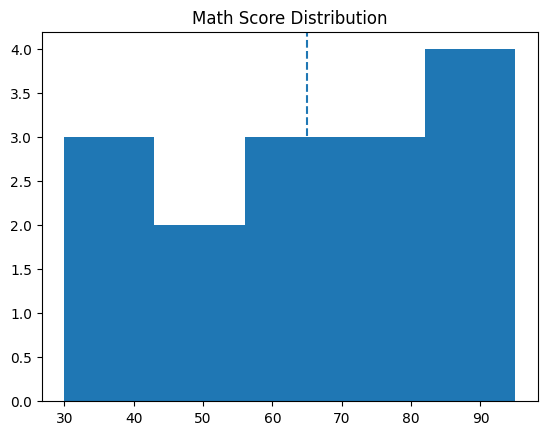

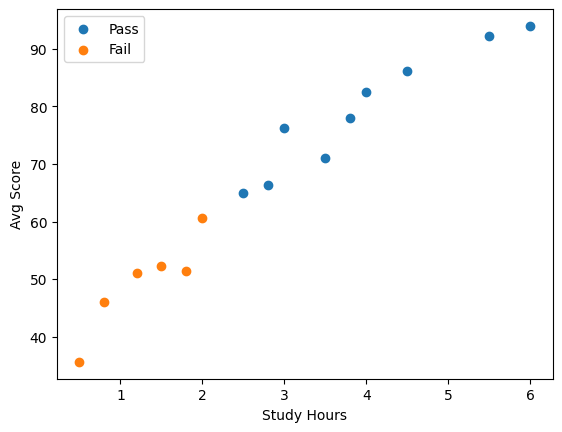

/tmp/ipykernel_1724/162217679.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass','Fail'])


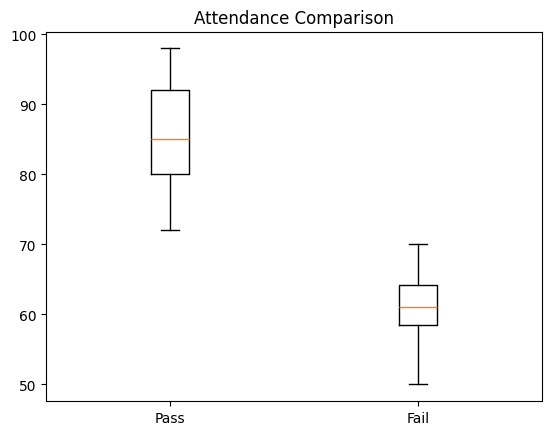

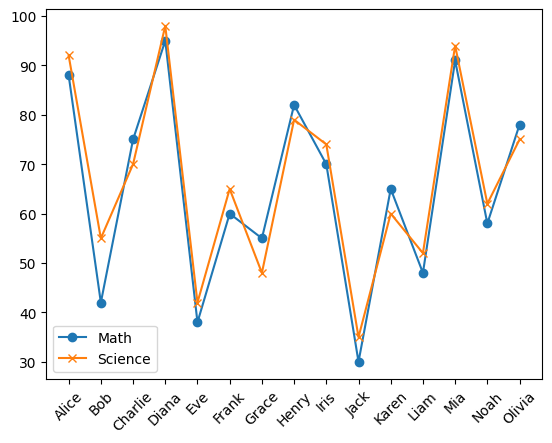

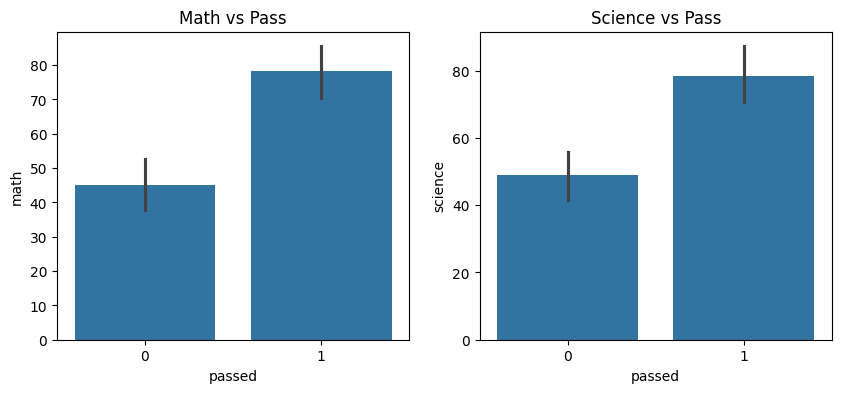

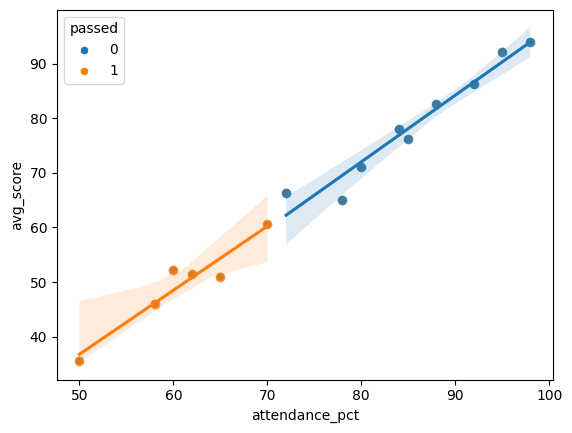

Training accuracy: 1.0
Test accuracy: 1.0
Jack 0 0 ✅
Liam 0 0 ✅
Alice 1 1 ✅

Feature importance:
english 0.8125127982724648
attendance_pct 0.521876340433209
study_hours_per_day 0.4844326627100155
pe 0.47497406284967797
math 0.43794393086873595
science 0.3230097624690249
history 0.26292892629062437


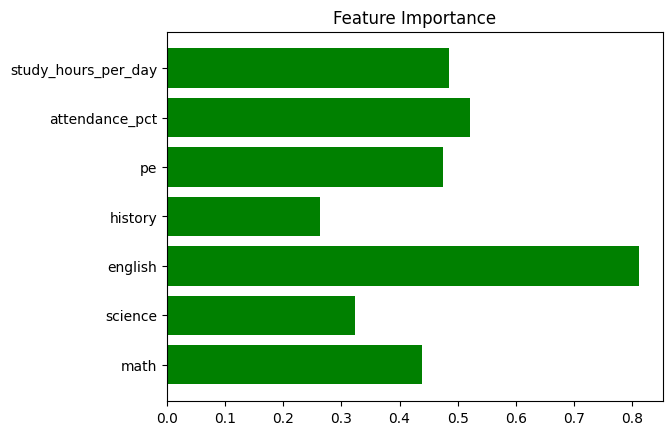

Prediction: Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
# ======================================
# Data Visualization & Machine Learning
# ======================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("student_performance.csv")

# =========================
# TASK 1 — Data Exploration
# =========================

print(df.head())

print("\nShape:", df.shape)
print("\nData types:\n", df.dtypes)

print("\nSummary stats:\n", df.describe())

print("\nPass/Fail count:\n", df['passed'].value_counts())

subject_cols = ['math','science','english','history','pe']

print("\nAverage scores (Pass):\n", df[df['passed']==1][subject_cols].mean())
print("\nAverage scores (Fail):\n", df[df['passed']==0][subject_cols].mean())

df['overall_avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['overall_avg'].idxmax()]
print("\nTop student:", top_student['name'])

# =============================
# Students statistics
# =============================

df['avg_score'] = df[subject_cols].mean(axis=1)

# =====================
# Plot 1 - Bar
# =====================

avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(avg_scores.index, avg_scores.values)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

# =========================
# Plot 2 - Histogram
# ==========================

mean_math = df['math'].mean()

plt.figure()
plt.hist(df['math'], bins=5)
plt.axvline(mean_math, linestyle='dashed')
plt.title("Math Score Distribution")
plt.savefig("plot2_hist.png")
plt.show()

# ==============
# Scatter Plot
# ==============

pass_df = df[df['passed']==1]
fail_df = df[df['passed']==0]

plt.figure()
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label='Fail')

plt.xlabel("Study Hours")
plt.ylabel("Avg Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

# =============
# Box
# =============

pass_att = pass_df['attendance_pct']
fail_att = fail_df['attendance_pct']

plt.figure()
plt.boxplot([pass_att, fail_att], labels=['Pass','Fail'])
plt.title("Attendance Comparison")
plt.savefig("plot4_box.png")
plt.show()

# =====
# Line
# =====

plt.figure()
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')

plt.xticks(rotation=45)
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

# =================
# Task 3 - SeaBorn
# =================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Math vs Pass")

plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Science vs Pass")

plt.savefig("plot6_seaborn_bar.png")
plt.show()

plt.figure()

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=pass_df, x='attendance_pct', y='avg_score')
sns.regplot(data=fail_df, x='attendance_pct', y='avg_score')

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# Seaborn was easier for creating attractive plots quickly.
# Matplotlib required more manual setup but gave more control.

# ============================
# TASK 4 — Machine Learning
# =============================

X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===================
# Model Training
# ===================

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("Training accuracy:", model.score(X_train_scaled, y_train))

# =============
# Evaluation
# =============

y_pred = model.predict(X_test_scaled)

print("Test accuracy:", model.score(X_test_scaled, y_test))

names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    status = "✅" if actual == pred else "❌"
    print(name, actual, pred, status)

# ========================
# Feature Importance
# ========================

import numpy as np

features = X.columns
coefs = model.coef_[0]

pairs = list(zip(features, coefs))
pairs.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature importance:")
for f, c in pairs:
    print(f, c)

colors = ['green' if c > 0 else 'red' for c in coefs]

plt.figure()
plt.barh(features, coefs, color=colors)
plt.title("Feature Importance")
plt.savefig("feature_importance.png")
plt.show()

# =================
# Probablity
# =================

new_student = [[75,70,68,65,80,82,3.2]]
new_scaled = scaler.transform(new_student)

pred = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

print("Prediction:", "Pass" if pred[0]==1 else "Fail")
print("Probability:", prob)